<a href="https://colab.research.google.com/github/keirabasma/Formation-IA/blob/main/workshop3_chelghoum_AAPL%20data%20set%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# ==========================================================
# Workshop: Financial Data Exploration and Visualization
# Dataset: AAPL Stock Market Data
# Platform: Google Colab
# ==========================================================


# ----------------------------------------------------------
# Import required libraries
# ----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [12]:
from google.colab import files
uploaded_files = files.upload()

Saving AAPL (1).csv to AAPL (1).csv


In [14]:
# ----------------------------------------------------------
# Load the uploaded dataset
# ----------------------------------------------------------
file_name = list(uploaded_files.keys())[0]
df = pd.read_csv("AAPL (1).csv")

print("Preview of the dataset:")
display(df.head())

print("\nDataset structure:")
print(df.info())

Preview of the dataset:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
1,2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2,2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
3,2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
4,2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600



Dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       184 non-null    object 
 1   Open       184 non-null    float64
 2   High       184 non-null    float64
 3   Low        184 non-null    float64
 4   Close      184 non-null    float64
 5   Adj Close  184 non-null    float64
 6   Volume     184 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 10.2+ KB
None


In [15]:
# ----------------------------------------------------------
# Data preparation and cleaning
# ----------------------------------------------------------
# Convert date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Convert numerical columns explicitly
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows with missing values
df.dropna(inplace=True)

print("\nCleaned dataset shape:", df.shape)



Cleaned dataset shape: (184, 7)


In [16]:
# ----------------------------------------------------------
# Descriptive statistics
# ----------------------------------------------------------
print("\nStatistical summary:")
display(df[numeric_columns].describe())


Statistical summary:


,Open,High,Low,Close,Volume
count,184.000000,184.000000,184.000000,184.000000,1.840000e+02
mean,127.040245,129.918098,124.340381,127.352663,1.910168e+08
std,24.314449,24.577906,24.176736,24.356534,8.160281e+07
min,92.389999,93.769997,89.470001,90.519997,3.839850e+07
25%,108.882499,112.362499,106.152502,109.204998,1.273706e+08
50%,118.895000,120.865002,116.870003,119.190002,1.744112e+08
75%,144.935005,147.695000,143.227493,144.704994,2.207755e+08
max,180.289993,183.500000,177.619995,179.979996,5.003630e+08


In [18]:
# ----------------------------------------------------------
# Feature engineering: daily returns
# ----------------------------------------------------------
df['Daily_Return'] = df['Close'].pct_change()
df.dropna(inplace=True)

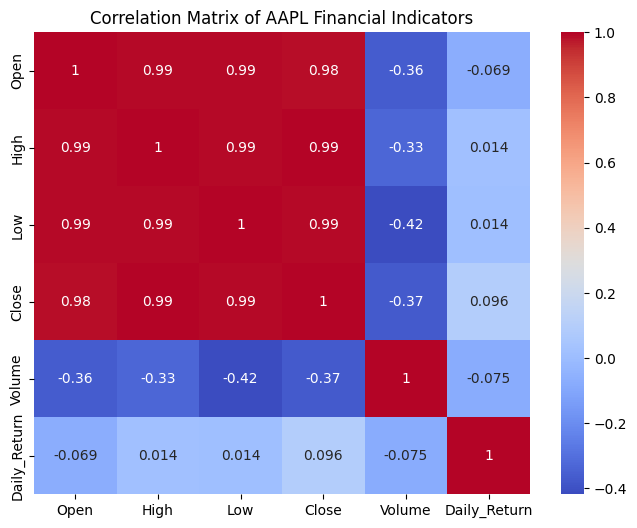

In [19]:
# ----------------------------------------------------------
# Correlation analysis between numerical indicators
# ----------------------------------------------------------
correlation_matrix = df[numeric_columns + ['Daily_Return']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of AAPL Financial Indicators")
plt.show()



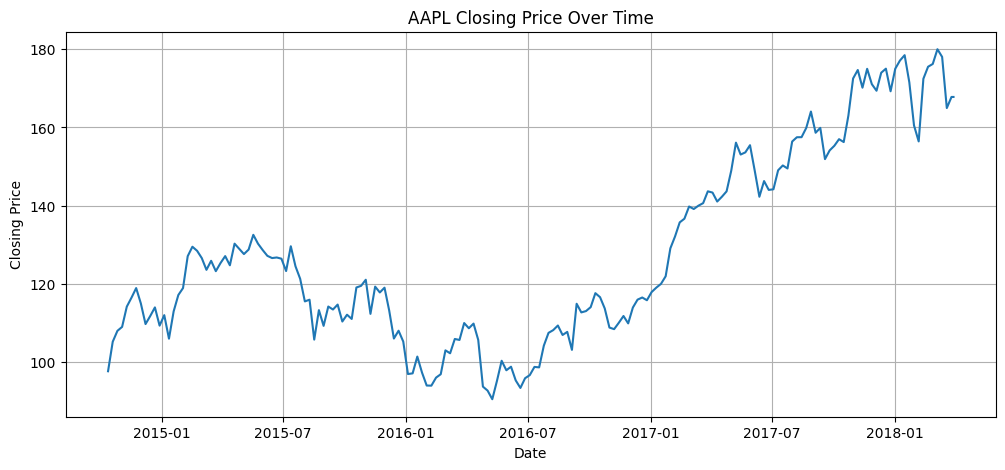

In [20]:
# ----------------------------------------------------------
# Time-series visualization: closing price
# ----------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'])
plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

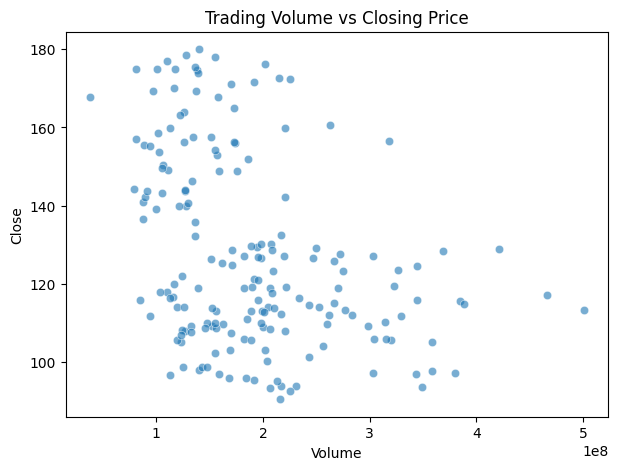

In [21]:
# ----------------------------------------------------------
# Relationship between trading volume and price
# ----------------------------------------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Volume', y='Close', alpha=0.6)
plt.title("Trading Volume vs Closing Price")
plt.show()

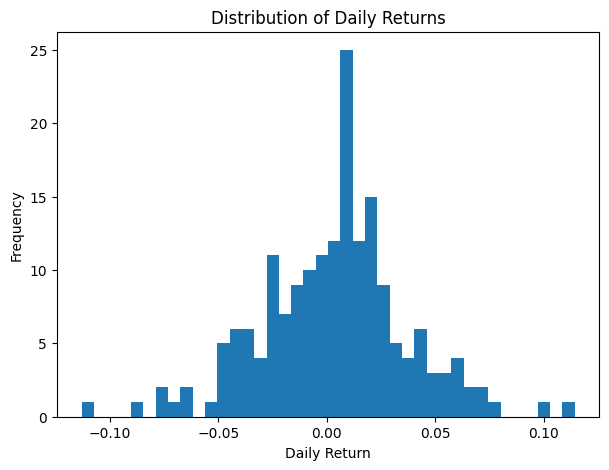

In [22]:
# ----------------------------------------------------------
# Distribution of daily returns
# ----------------------------------------------------------
plt.figure(figsize=(7,5))
plt.hist(df['Daily_Return'], bins=40)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

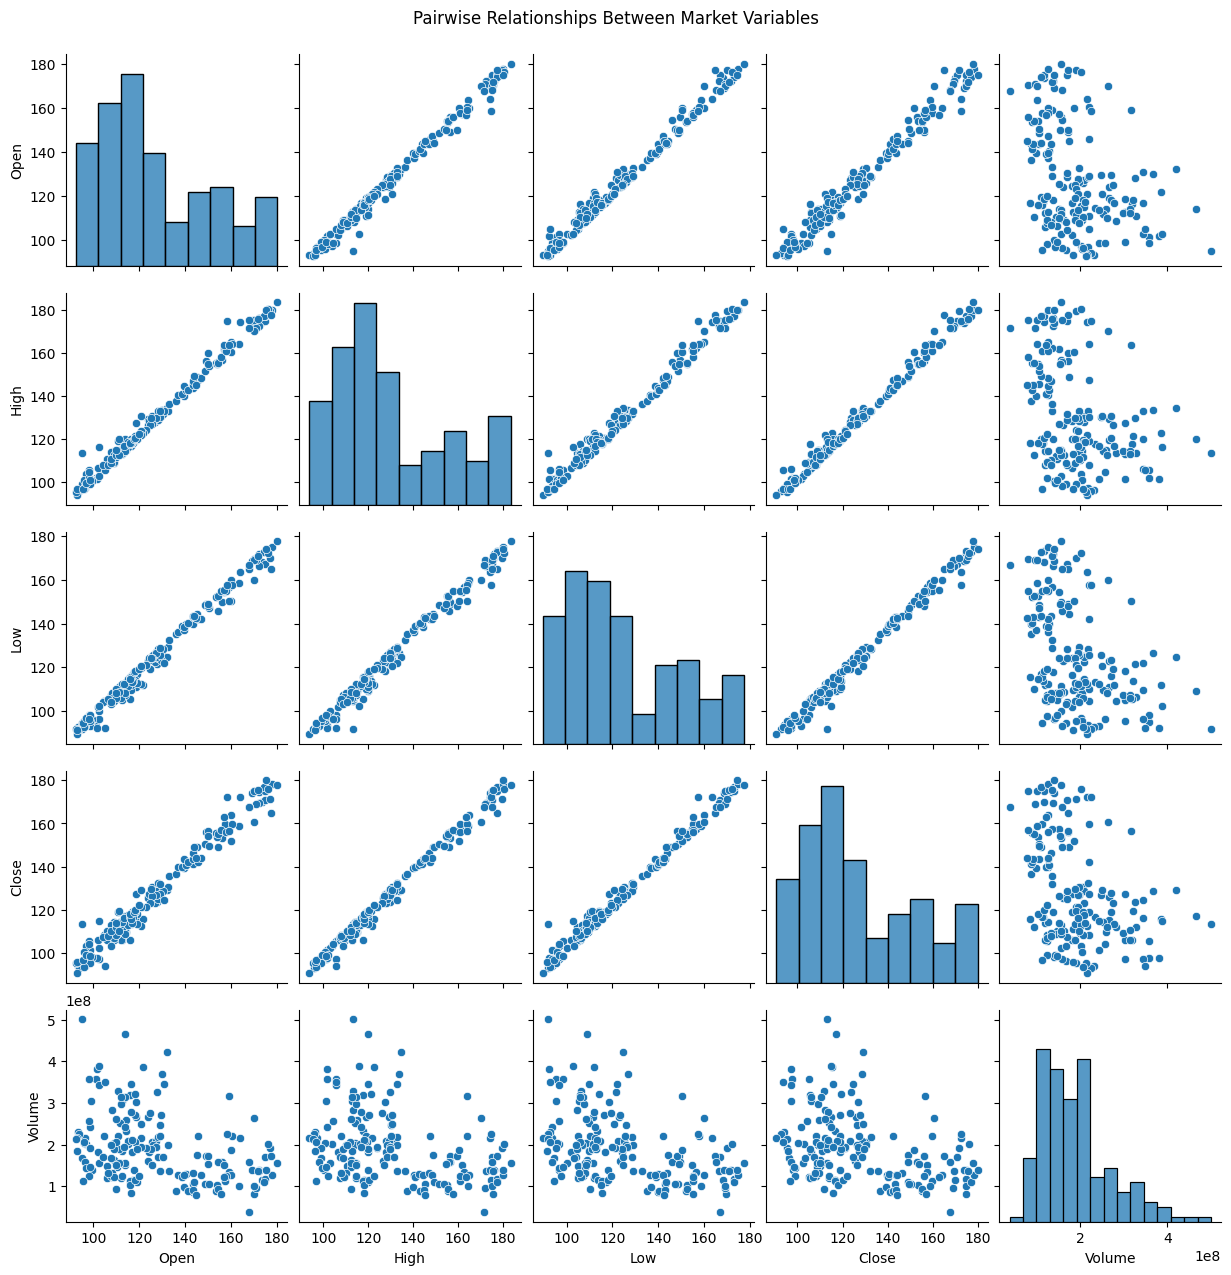

In [23]:
# ----------------------------------------------------------
# Multivariate exploration
# ----------------------------------------------------------
sns.pairplot(df[['Open', 'High', 'Low', 'Close', 'Volume']])
plt.suptitle("Pairwise Relationships Between Market Variables", y=1.02)
plt.show()


In [24]:
# ----------------------------------------------------------
# Interactive visualizations with Plotly
# ----------------------------------------------------------
px.line(
    df,
    x='Date',
    y='Close',
    title="Interactive Trend of AAPL Closing Price"
).show()

px.scatter(
    df,
    x='Volume',
    y='Close',
    title="Interactive Volume vs Closing Price",
    opacity=0.6
).show()

px.box(
    df,
    y='Daily_Return',
    title="Interactive Boxplot of Daily Returns"
).show()


In [25]:
# ----------------------------------------------------------
# Final observations
# ----------------------------------------------------------
print("Key insights:")
print("- The closing price shows a clear long-term trend with short-term volatility.")
print("- Trading volume fluctuates independently but spikes during strong price movements.")
print("- High correlations between Open, High, Low, and Close are expected in stock data.")
print("- Daily returns are centered around zero, indicating normal market behavior.")

Key insights:
- The closing price shows a clear long-term trend with short-term volatility.
- Trading volume fluctuates independently but spikes during strong price movements.
- High correlations between Open, High, Low, and Close are expected in stock data.
- Daily returns are centered around zero, indicating normal market behavior.
